# L2 · 강도감소계수 $\phi$ 는 왜 상수가 아닌가

## 이 시간에 답할 질문

1. $\phi$ 를 표에서 찾는 숫자로 외우는데, 실은 무엇의 함수인가?
2. 왜 압축지배단면은 $\phi = 0.65$ 로 **벌점**을 받는가?
3. P-M 상관도에서 설계 곡선은 왜 공칭 곡선과 **평행하지 않은가**?
4. 나선철근 기둥은 왜 $\phi$ 와 $\alpha$ 를 모두 우대받는가?

## 필요한 배경

변형률 적합조건, 등가직사각형 응력블록, P-M 상관도의 개념.

## 근거 조문

| 내용 | 조문 |
|---|---|
| 강도감소계수 $\phi$ 의 값과 변화구간 보간 | KDS 14 20 10 4.3.3(2) |
| 압축지배변형률한계 $\varepsilon_y$ | KDS 14 20 20 4.1.2(3) |
| 인장지배변형률한계 $\varepsilon_{t,tl}$ | KDS 14 20 20 4.1.2(4) |
| 최대 설계 축강도 $\alpha\phi P_o$ | KDS 14 20 20 식 (4.1-16), (4.1-17) |

In [1]:
%matplotlib inline

import glob
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다."""
    site = Path(sys.prefix, "lib", f"python{sys.version_info.major}.{sys.version_info.minor}", "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Malgun Gothic", "AppleGothic",
                 "Noto Sans CJK KR", "Noto Sans KR", "WenQuanYi Zen Hei"):
        if name in installed:
            plt.rcParams["font.family"] = name
            return name

    warnings.warn(
        "한글 글꼴을 찾지 못했다. 그림의 한글이 깨진다면 "
        "`pip install koreanize-matplotlib` 로 글꼴만 내려받거나, "
        "나눔고딕·Noto Sans KR 을 시스템에 설치한다.",
        stacklevel=2,
    )
    return None


print("사용 글꼴:", use_korean_font())

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

사용 글꼴: NanumGothic


In [2]:
C_COMP, C_TRAN, C_TENS = "#d1495b", "#edae49", "#2e8b57"

BAND_LABEL = {
    "압축지배단면": C_COMP,
    "변화구간단면": C_TRAN,
    "인장지배단면": C_TENS,
}

## 1. 준비 — 기둥 단면 하나

500 × 500 띠철근 기둥, 8-D22, $f_{ck} = 27$ MPa, SD400.

SD400 이므로 $\varepsilon_y = f_y/E_s = 400/200{,}000 = 0.002$ 이고,
인장지배한계는 $\max(0.005,\ 2.5\varepsilon_y) = 0.005$ 이다.

In [3]:
from concreteproperties import ConcreteSection
from sectionproperties.pre.library import concrete_rectangular_section

from concreteproperties_kds import KDS


def column_section(fck=27, fy=400, column_type="tie"):
    """500 x 500 기둥 단면 (8-D22, 피복 50 mm)."""
    kds = KDS(column_type=column_type)
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=500, b=500,
        dia_top=22, area_top=387.1, n_top=3, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=3, c_bot=50,
        dia_side=22, area_side=387.1, n_side=1, c_side=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec


kds, conc_sec = column_section()

print(f"압축지배변형률한계  eps_y  = {kds.eps_y:.5f}")
print(f"인장지배변형률한계  eps_tl = {kds.eps_tl:.5f}")
print(f"압축지배단면의 phi         = {kds.phi_comp:.2f}  ({'나선철근' if kds.column_type == 'spiral' else '띠철근'})")
print("인장지배단면의 phi         = 0.85")

압축지배변형률한계  eps_y  = 0.00200
인장지배변형률한계  eps_tl = 0.00500
압축지배단면의 phi         = 0.65  (띠철근)
인장지배단면의 phi         = 0.85


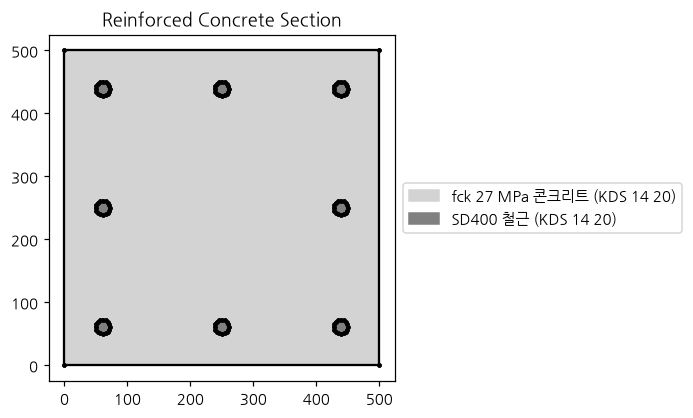

<Axes: title={'center': 'Reinforced Concrete Section'}>

In [4]:
conc_sec.plot_section()

## 2. $\phi$ 는 무엇의 함수인가

먼저 답부터 보자. $\phi$ 는 **최외단 인장철근의 순인장변형률
$\varepsilon_t$ 의 함수**다. 축력이나 단면 크기의 함수가 아니다.

$$
\phi(\varepsilon_t) =
\begin{cases}
0.65 & \varepsilon_t \le \varepsilon_y \quad \text{(압축지배)} \\[4pt]
0.65 + 0.20\,\dfrac{\varepsilon_t - \varepsilon_y}{\varepsilon_{t,tl} - \varepsilon_y}
      & \varepsilon_y < \varepsilon_t < \varepsilon_{t,tl} \quad \text{(변화구간)} \\[8pt]
0.85 & \varepsilon_t \ge \varepsilon_{t,tl} \quad \text{(인장지배)}
\end{cases}
$$

**볼 것:** 아래 그림에서 $\phi$ 가 계단이 아니라 **경사로**라는 점.
변화구간을 둔 이유는 파괴 양상이 취성에서 연성으로 서서히 바뀌기
때문이다. 경계에서 강도가 뚝 떨어지면 설계가 불연속이 된다.

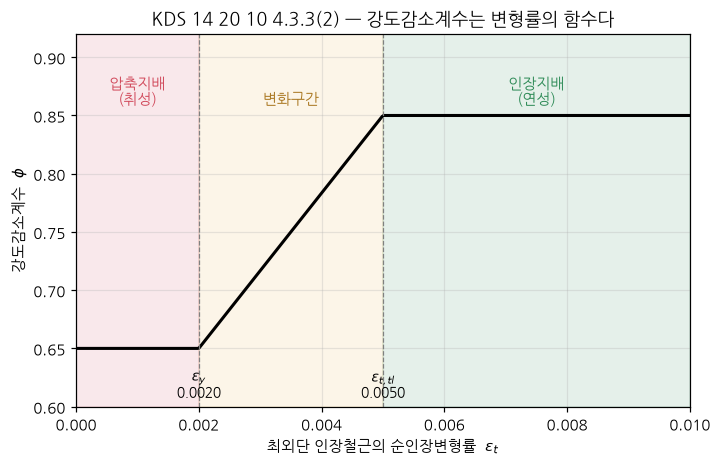

In [5]:
eps = np.linspace(0.0, 0.010, 400)
phi = np.array([kds.capacity_reduction_factor(e) for e in eps])

fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.axvspan(0, kds.eps_y, color=C_COMP, alpha=0.12)
ax.axvspan(kds.eps_y, kds.eps_tl, color=C_TRAN, alpha=0.12)
ax.axvspan(kds.eps_tl, eps[-1], color=C_TENS, alpha=0.12)

ax.plot(eps, phi, color="k", lw=2)

for x, label in [(kds.eps_y, r"$\varepsilon_y$"),
                 (kds.eps_tl, r"$\varepsilon_{t,tl}$")]:
    ax.axvline(x, color="grey", ls="--", lw=0.8)
    ax.annotate(f"{label}\n{x:.4f}", xy=(x, 0.606),
                ha="center", va="bottom", fontsize=9)

ax.text(kds.eps_y / 2, 0.86, "압축지배\n(취성)", ha="center", color=C_COMP)
ax.text((kds.eps_y + kds.eps_tl) / 2, 0.86, "변화구간", ha="center", color="#a9761f")
ax.text((kds.eps_tl + eps[-1]) / 2, 0.86, "인장지배\n(연성)", ha="center", color=C_TENS)

ax.set_xlabel(r"최외단 인장철근의 순인장변형률  $\varepsilon_t$")
ax.set_ylabel(r"강도감소계수  $\phi$")
ax.set_title("KDS 14 20 10 4.3.3(2) — 강도감소계수는 변형률의 함수다")
ax.set_ylim(0.60, 0.92)
ax.set_xlim(0, eps[-1])
plt.show()

**여기서 알 것:** 표에 적힌 0.65 와 0.85 는 이 함수의 **양 끝값**일
뿐이다. 실제 기둥은 대부분 그 사이 어딘가에 있다.

"압축지배단면은 $\phi = 0.65$" 를 외운 학생은 변화구간에 있는 기둥에서
$\phi$ 를 0.65 로 잡아 강도를 과소평가하거나, 반대로 0.85 로 잡아
**위험측 설계**를 하게 된다.

## 3. 왜 취성 파괴에 벌점을 주는가

$\phi$ 는 "재료가 약할까 봐" 곱하는 계수가 아니다. 그건 재료계수의
역할이고, KDS 의 $\phi$ 에는 **파괴 양상에 대한 벌점**이 섞여 있다.

- **인장지배**($\varepsilon_t \ge 0.005$) — 철근이 충분히 항복한 뒤
  콘크리트가 압괴한다. 처짐과 균열로 미리 경고가 오고, 파괴까지
  여유가 있다. → $\phi = 0.85$
- **압축지배**($\varepsilon_t \le \varepsilon_y$) — 철근이 항복하기
  전에 콘크리트가 먼저 깨진다. 경고 없이 갑자기 무너진다.
  → $\phi = 0.65$

같은 공칭강도라도 **경고 없이 무너지는 단면은 더 큰 안전여유를
요구한다**는 뜻이다.

## 4. 단면 위에서 확인하기

축력을 인장에서 압축까지 훑으면서 $\varepsilon_t$, 분류, $\phi$ 를
함께 본다.

**볼 것:** 축력이 커질수록 중립축이 깊어져 $\varepsilon_t$ 가 줄고,
어느 지점에서 인장지배 → 변화구간 → 압축지배로 넘어간다.

In [6]:
rows = []
for n_d in [-800, -400, 0, 300, 600, 900, 1200, 1600, 2000, 2600, 3200]:
    f_res, u_res, phi_i = kds.ultimate_bending_capacity(n_design=n_d * 1e3)
    e_t = kds.net_tensile_strain(theta=0, d_n=u_res.d_n)
    rows.append((n_d, u_res.d_n, e_t, kds.section_classification(e_t),
                 phi_i, f_res.m_x / 1e6))

print(f"{'Nd(kN)':>8} {'중립축 dn(mm)':>13} {'eps_t':>9} {'단면 분류':>12}"
      f" {'phi':>6} {'phiMn(kNm)':>11}")
print("-" * 66)
for n_d, d_n, e_t, cls, phi_i, m in rows:
    e_str = "    inf" if e_t == float("inf") else f"{e_t:7.5f}"
    print(f"{n_d:8.0f} {d_n:13.1f} {e_str:>9} {cls:>12} {phi_i:6.3f} {m:11.1f}")

  Nd(kN)    중립축 dn(mm)     eps_t        단면 분류    phi  phiMn(kNm)
------------------------------------------------------------------
    -800           0.0       inf       인장지배단면  0.850        52.1
    -400           0.0       inf       인장지배단면  0.850       134.6
       0          72.3   0.01675       인장지배단면  0.850       217.0
     300          95.5   0.01187       인장지배단면  0.850       272.7
     600         122.3   0.00855       인장지배단면  0.850       323.9
     900         152.5   0.00620       인장지배단면  0.850       369.1
    1200         181.7   0.00467       변화구간단면  0.828       386.2
    1600         262.5   0.00222       변화구간단면  0.665       345.6
    2000         311.5   0.00135       압축지배단면  0.650       325.4
    2600         382.9   0.00048       압축지배단면  0.650       288.9
    3200         461.0  -0.00016       압축지배단면  0.650       229.7


## 5. P-M 상관도 위에 칠해 보기

상관도의 각 점을 그 점의 $\varepsilon_t$ 로 분류해 색을 입힌다.

**볼 것:** 상관도의 **아래쪽(인장측)은 초록, 위쪽(압축측)은 빨강**이다.
축력이 클수록 취성 파괴에 가까워진다는 사실이 곡선 하나에 담긴다.
균형점(balanced point)은 빨강과 노랑이 만나는 곳이다.

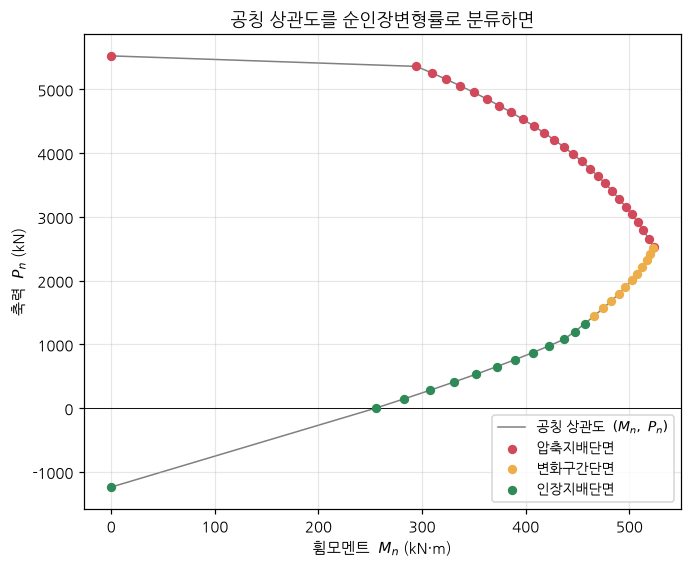

In [7]:
f_mi, mi, phis = kds.moment_interaction_diagram(n_points=48, progress_bar=False)

n_nom = np.array([r.n for r in mi.results]) / 1e3
m_nom = np.array([r.m_x for r in mi.results]) / 1e6
n_des = np.array([r.n for r in f_mi.results]) / 1e3
m_des = np.array([r.m_x for r in f_mi.results]) / 1e6

eps_t = np.array([kds.net_tensile_strain(theta=0, d_n=r.d_n) for r in mi.results])
cls = [kds.section_classification(e) for e in eps_t]

fig, ax = plt.subplots(figsize=(7.0, 5.6))

ax.plot(m_nom, n_nom, color="grey", lw=1.0, zorder=1,
        label=r"공칭 상관도  $(M_n,\ P_n)$")
for name, color in BAND_LABEL.items():
    sel = [i for i, c in enumerate(cls) if c == name]
    ax.scatter(m_nom[sel], n_nom[sel], s=26, color=color,
               zorder=3, label=name)

ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("휨모멘트  $M_n$ (kN·m)")
ax.set_ylabel("축력  $P_n$ (kN)")
ax.set_title("공칭 상관도를 순인장변형률로 분류하면")
ax.legend(loc="lower right", fontsize=9)
plt.show()

## 6. 상관도를 따라 $\phi$ 가 어떻게 변하는가

같은 상관도의 각 점에서 $\phi$ 만 뽑아 축력에 대해 그린다.

**볼 것:** 2절의 $\phi(\varepsilon_t)$ 곡선과 **같은 모양이 뒤집혀**
나타난다. 축력이 커질수록 $\varepsilon_t$ 가 줄기 때문이다.

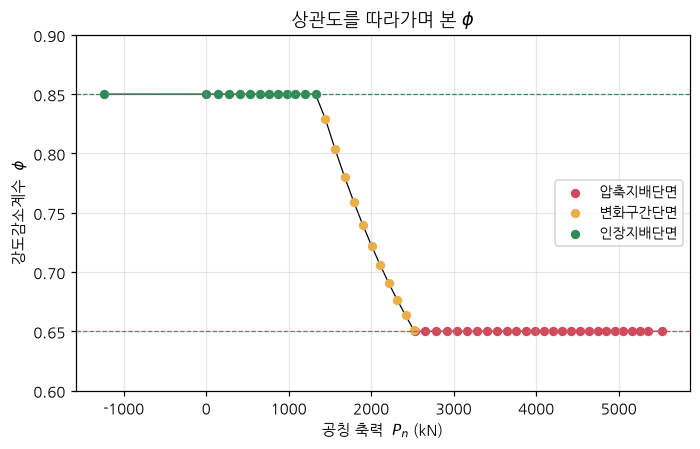

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

phis_arr = np.array(phis)
for name, color in BAND_LABEL.items():
    sel = [i for i, c in enumerate(cls) if c == name]
    ax.scatter(n_nom[sel], phis_arr[sel], s=26, color=color, label=name)

ax.plot(n_nom, phis_arr, color="k", lw=0.8, zorder=0)
ax.axhline(0.85, color=C_TENS, ls="--", lw=0.8)
ax.axhline(kds.phi_comp, color=C_COMP, ls="--", lw=0.8)

ax.set_xlabel("공칭 축력  $P_n$ (kN)")
ax.set_ylabel(r"강도감소계수  $\phi$")
ax.set_title(r"상관도를 따라가며 본 $\phi$")
ax.set_ylim(0.60, 0.90)
ax.legend(fontsize=9)
plt.show()

## 7. 설계 곡선은 왜 공칭 곡선과 평행하지 않은가

여기가 이 시간의 핵심이다. 설계 상관도는 공칭 상관도에 **일정한 수를
곱한 것이 아니다.** 점마다 다른 $\phi$ 가 곱해진다.

게다가 압축측은 최대 설계 축강도
$\alpha\phi P_o$ 에서 **잘린다**(KDS 14 20 20 식 (4.1-16), (4.1-17)).
띠철근은 $\alpha = 0.80$, 나선철근은 $0.85$ 다. 이는 우발 편심을
고려한 상한이다.

**볼 것:** 두 곡선의 간격이 위아래로 다르다. 인장측에서는 좁고
(곱하는 값이 0.85), 압축측에서는 넓다(0.65).

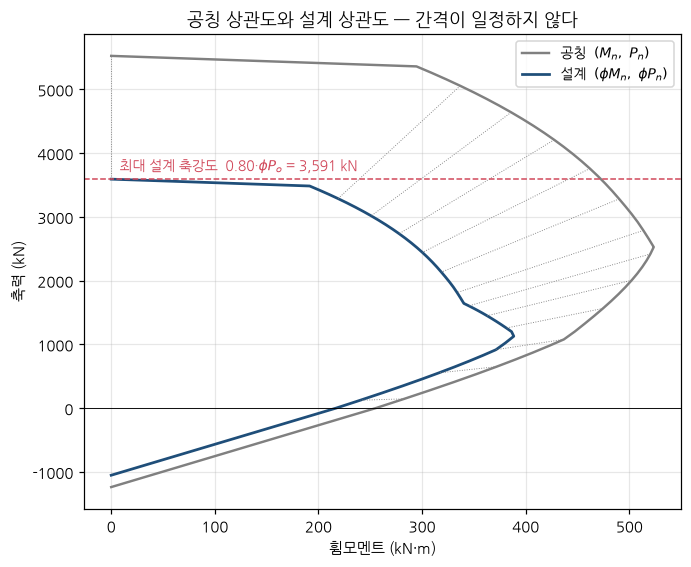

In [9]:
n_max_nom, n_max_des = kds.max_axial_strength()

fig, ax = plt.subplots(figsize=(7.0, 5.6))

ax.plot(m_nom, n_nom, color="grey", lw=1.6, label=r"공칭  $(M_n,\ P_n)$")
ax.plot(m_des, n_des, color="#1f4e79", lw=1.8,
        label=r"설계  $(\phi M_n,\ \phi P_n)$")

# 같은 축력 지점끼리 이어 간격을 보인다
for i in range(0, len(m_nom), 4):
    ax.plot([m_nom[i], m_des[i]], [n_nom[i], n_des[i]],
            color="grey", lw=0.6, ls=":")

ax.axhline(n_max_des / 1e3, color=C_COMP, ls="--", lw=1.0)
ax.annotate(rf"최대 설계 축강도  {kds.alpha_max:.2f}·$\phi P_o$ = {n_max_des / 1e3:,.0f} kN",
            xy=(8, n_max_des / 1e3 + 90), fontsize=9,
            ha="left", va="bottom", color=C_COMP)

ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("휨모멘트 (kN·m)")
ax.set_ylabel("축력 (kN)")
ax.set_title("공칭 상관도와 설계 상관도 — 간격이 일정하지 않다")
ax.legend(loc="upper right", fontsize=9)
plt.show()

두 곡선의 **비**를 직접 그리면 그것이 곧 $\phi$ 다. 당연한 이야기지만,
상관도를 보며 "왜 안쪽으로 파고드는 정도가 다르지?" 하고 의아해하던
학생에게는 이 그림이 답이 된다.

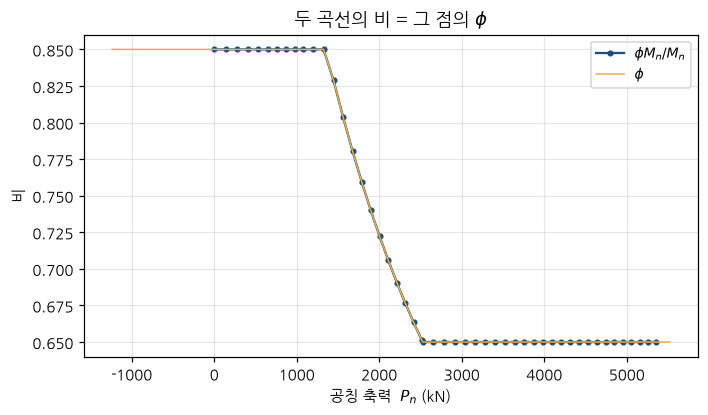

In [10]:
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(np.abs(m_nom) > 1e-6, m_des / m_nom, np.nan)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(n_nom, ratio, "o-", ms=3, color="#1f4e79", label=r"$\phi M_n / M_n$")
ax.plot(n_nom, phis_arr, lw=1.0, color=C_TRAN, label=r"$\phi$")
ax.set_xlabel("공칭 축력  $P_n$ (kN)")
ax.set_ylabel("비")
ax.set_title(r"두 곡선의 비 = 그 점의 $\phi$")
ax.legend(fontsize=9)
plt.show()

## 8. 띠철근과 나선철근

나선철근 기둥은 두 가지를 우대받는다.

| | 띠철근 | 나선철근 |
|---|---|---|
| 압축지배단면의 $\phi$ | 0.65 | **0.70** |
| 최대 축강도 계수 $\alpha$ | 0.80 | **0.85** |

이유는 나선철근이 심부 콘크리트를 **구속**해서, 피복이 떨어져 나간
뒤에도 축력을 유지하며 변형을 이어 가기 때문이다. 즉 압축파괴가
덜 급작스럽다.

**볼 것:** 나선철근 상관도가 압축측에서 바깥으로 밀려난다. 휨이
지배하는 아래쪽에서는 두 곡선이 겹친다 — 그쪽은 어차피 $\phi = 0.85$
로 같기 때문이다.

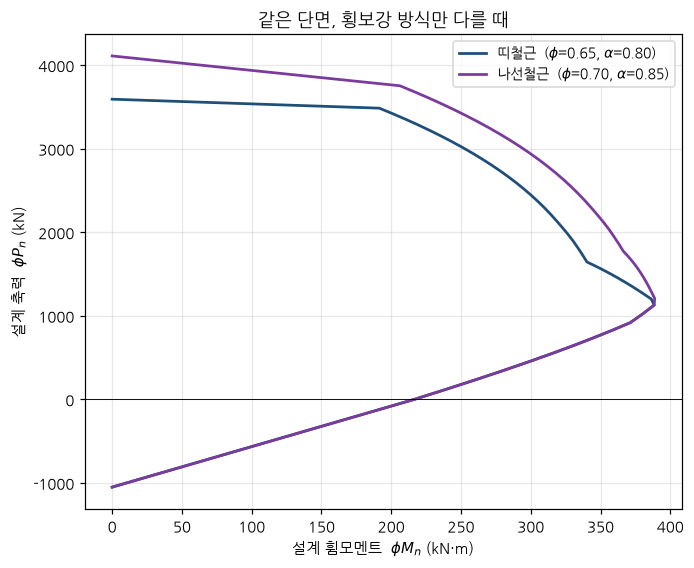

In [11]:
kds_s, _ = column_section(column_type="spiral")
f_mi_s, _, _ = kds_s.moment_interaction_diagram(n_points=48, progress_bar=False)

m_s = np.array([r.m_x for r in f_mi_s.results]) / 1e6
n_s = np.array([r.n for r in f_mi_s.results]) / 1e3

fig, ax = plt.subplots(figsize=(7.0, 5.6))
ax.plot(m_des, n_des, lw=1.8, color="#1f4e79", label=r"띠철근  ($\phi$=0.65, $\alpha$=0.80)")
ax.plot(m_s, n_s, lw=1.8, color="#7a3b9c", label=r"나선철근  ($\phi$=0.70, $\alpha$=0.85)")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel(r"설계 휨모멘트  $\phi M_n$ (kN·m)")
ax.set_ylabel(r"설계 축력  $\phi P_n$ (kN)")
ax.set_title("같은 단면, 횡보강 방식만 다를 때")
ax.legend(loc="upper right", fontsize=9)
plt.show()

In [12]:
_, n_max_des_t = kds.max_axial_strength()
_, n_max_des_s = kds_s.max_axial_strength()

print(f"{'':14}{'띠철근':>12}{'나선철근':>12}{'차이':>10}")
print("-" * 48)
print(f"{'최대 설계 축강도':14}{n_max_des_t / 1e3:10,.0f} kN"
      f"{n_max_des_s / 1e3:10,.0f} kN"
      f"{(n_max_des_s / n_max_des_t - 1) * 100:9.1f} %")

for n_d in [1500, 2500]:
    m_t = kds.ultimate_bending_capacity(n_design=n_d * 1e3)[0].m_x / 1e6
    m_s_ = kds_s.ultimate_bending_capacity(n_design=n_d * 1e3)[0].m_x / 1e6
    print(f"{f'phiMn @ {n_d} kN':14}{m_t:10,.1f} kNm{m_s_:9,.1f} kNm"
          f"{(m_s_ / m_t - 1) * 100:9.1f} %")

                       띠철근        나선철근        차이
------------------------------------------------
최대 설계 축강도          3,591 kN     4,109 kN     14.4 %


phiMn @ 1500 kN     357.2 kNm    379.3 kNm      6.2 %


phiMn @ 2500 kN     296.2 kNm    331.7 kNm     12.0 %


## 9. 직접 바꿔 보기

아래 셀의 값을 바꾸고 **다시 실행**해 보라.

- `fy = 500` 또는 `600` — $\varepsilon_y = f_y/E_s$ 가 커지므로
  인장지배 조건이 빡빡해진다. 인장지배한계도
  $\max(0.005,\ 2.5\varepsilon_y)$ 로 함께 움직인다.
- `fck = 40` 또는 `60` — 응력블록 계수 $\eta,\ \beta_1$ 과
  $\varepsilon_{cu}$ 가 바뀐다(KDS 14 20 20 표 4.1-2).

fy = 600 MPa,  fck = 27 MPa
  eps_y  = 0.00300   (= fy / 200,000)
  eps_tl = 0.00750   (= max(0.005, 2.5*eps_y))
  변화구간 폭 = 0.00450


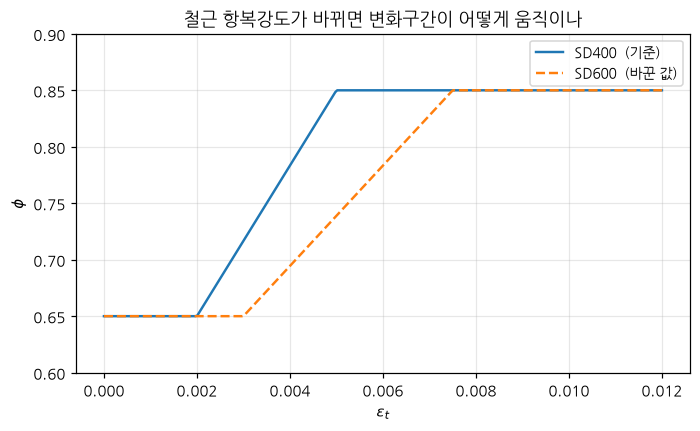

In [13]:
fy = 600     # ← 400, 500, 600 으로 바꿔 보라
fck = 27     # ← 27, 40, 60 으로 바꿔 보라

kds_x, _ = column_section(fck=fck, fy=fy)

print(f"fy = {fy} MPa,  fck = {fck} MPa")
print(f"  eps_y  = {kds_x.eps_y:.5f}   (= fy / 200,000)")
print(f"  eps_tl = {kds_x.eps_tl:.5f}   (= max(0.005, 2.5*eps_y))")
print(f"  변화구간 폭 = {kds_x.eps_tl - kds_x.eps_y:.5f}")

eps_x = np.linspace(0, 0.012, 300)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(eps_x, [kds.capacity_reduction_factor(e) for e in eps_x],
        lw=1.6, label="SD400  (기준)")
ax.plot(eps_x, [kds_x.capacity_reduction_factor(e) for e in eps_x],
        lw=1.6, ls="--", label=f"SD{fy}  (바꾼 값)")
ax.set_xlabel(r"$\varepsilon_t$")
ax.set_ylabel(r"$\phi$")
ax.set_title("철근 항복강도가 바뀌면 변화구간이 어떻게 움직이나")
ax.set_ylim(0.60, 0.90)
ax.legend(fontsize=9)
plt.show()

## 10. 생각해 볼 문제

정답을 바로 계산하지 말고, 먼저 답을 예상한 뒤 위 코드로 확인해 보라.

1. **SD600 을 쓰면 왜 인장지배단면을 만들기 어려워지는가?**
   $\varepsilon_{t,tl} = \max(0.005,\ 2.5\varepsilon_y)$ 에서
   SD600 의 $\varepsilon_y = 0.003$ 이므로 한계가 0.0075 로 올라간다.
   이것이 설계에 어떤 부담을 주는가?

2. **철근비를 늘리면 $\phi M_n$ 은 계속 커지는가?**
   휨부재에서 인장철근을 계속 늘려 보라. 어느 지점부터 $\phi$ 가
   떨어지기 시작하고, $\phi M_n$ 의 증가가 둔해진다. 그 지점의
   물리적 의미는?

3. **$\phi$ 를 곱한 뒤 상관도가 안쪽으로 들어오는데, 압축측 상한선
   $\alpha\phi P_o$ 는 왜 또 따로 필요한가?**
   $\phi$ 만으로는 무엇을 막지 못하는가?

4. **나선철근의 우대를 받으려면 어떤 조건을 만족해야 하는가?**
   KDS 14 20 50 의 나선철근 상세 규정을 찾아보고, 조건을 못 지킨
   나선철근 기둥은 어떻게 취급해야 할지 논하라.

## 정리

- $\phi$ 는 표에서 찾는 상수가 아니라 $\varepsilon_t$ 의 **연속 함수**다.
- 벌점의 근거는 재료의 불확실성이 아니라 **파괴의 예고 여부**다.
- 그래서 설계 상관도는 공칭 상관도와 평행할 수 없다.
- 압축측 절단($\alpha\phi P_o$)은 $\phi$ 와 별개의 장치로, 우발 편심을 막는다.

조문과 구현 함수의 대응은
[설계식 목록](../user_guide/design_codes/equations.md) 에 정리되어 있다.